# Avance 2. Fase de Ingeniería de Características
**Proyecto:** Detección y clasificación de fuentes en imágenes astronómicas  
**Colaboradores:** Instituto de Astronomía, UNAM / LSST México / Observatorio Vera C. Rubin

### ***Resumen Inicial: Fase de Ingeniería de Características (FE)***

***

### ***Contexto de la Metodología CRISP-ML***
En esta etapa, nos situamos en la fase de **Preparación de Datos**. El objetivo es transformar los datos astronómicos crudos (archivos FITS) en un conjunto de datos estructurado y optimizado que facilite el aprendizaje de modelos de Deep Learning.

### ***Objetivos de este Notebook:***
* ***Construcción de Características:*** Extraeremos recortes de imagen centrados en objetos validados por el catálogo SDSS. Generaremos métricas estadísticas (media, desviación estándar, máximo) para caracterizar la morfología de estrellas y galaxias.
* ***Normalización y Transformación:*** Aplicaremos una transformación **asinh** para comprimir el rango dinámico y un escalamiento **Min-Max [0, 1]** por cada objeto para estandarizar la entrada a la red neuronal.
* ***Data Augmentation:*** Enriqueceremos el dataset mediante rotaciones y reflexiones para que el modelo sea robusto ante la orientación de los objetos.
* ***Selección de Características:*** Utilizaremos un filtro de **SNR (Signal-to-Noise Ratio)** para asegurar que solo los objetos con señal clara sean procesados.
"""

---


**Equipo:** 23  


| NOMBRE | MATRÍCULA |
|------|------------|
|  |  |
| DAVID ADRIÁN GUEVARA GASPAR | A01796618 |
| URIEL ALEJANDRO GONZÁLEZ ROJO | A01048131 |
| URIEL DÍAZ VILLAMIL | A01422439 |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.vizier import Vizier
from astropy.visualization import ZScaleInterval
from astropy.stats import mad_std
import random
import matplotlib.patheffects as path_effects
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd
from scipy.ndimage import rotate
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType, StringType, ArrayType
from pyspark.sql.functions import col

In [2]:
# --- 1. RUTAS DE TUS ARCHIVOS ---
file_subaru = '/Users/urieldiazvillamil/Developer/Python/Vera Rubin/SUBARUCADC/SCLA_163.185+57.429.W-S-I.fits'
file_hubble = '/Users/urieldiazvillamil/Developer/Python/Vera Rubin/MAST_2026-05-12T2346/HST/hst_11967_41_wfpc2_pc_f606w_ub9t41/hst_11967_41_wfpc2_pc_f606w_ub9t41_drz.fits'

In [3]:
# --- CLASE ABSTRACTA  ---
class AbstractAstroManager(ABC):
    def __init__(self, data_sub, wcs_sub):
        self.data_sub = data_sub
        self.wcs_sub = wcs_sub
        self.zscale = ZScaleInterval()
        self.rms_sub = mad_std(data_sub) if data_sub.size > 0 else 1.0
        self.objetos_validados = []
        self.bias_x = 0.0
        self.bias_y = 0.0

    @abstractmethod
    def scale_asinh(self, data, non_linear): pass

    @abstractmethod
    def calibrar_bias_sistematico(self, n_muestras): pass

    @abstractmethod
    def escanear_campo_robusto(self, target_coord, radius_arcmin): pass

    @abstractmethod
    def generar_dataset_clasificado(self, box_size, snr_min): pass

    @abstractmethod
    def visualizar_clasificados(self, dataset, n, seed): pass

In [4]:
class SubaruDatasetManager(AbstractAstroManager):
    
    def scale_asinh(self, data, non_linear=2.0):
        """
        Transformación no lineal para comprimir el rango dinámico.
        Justificación: Los datos astronómicos tienen picos de flujo muy altos. 
        La función arcsinh preserva la linealidad en niveles bajos de ruido y 
        comprime logarítmicamente las señales altas (estrellas).
        """
        data_clean = np.nan_to_num(data)
        data_centered = data_clean - np.median(data_clean)
        v_max = np.percentile(data_centered, 99.5) + 1e-6
        scaled_data = data_centered / v_max
        return np.arcsinh(scaled_data * non_linear) / np.arcsinh(non_linear)

    def calibrar_bias_sistematico(self, n_muestras=50):
        if not self.objetos_validados: return
        offsets_x, offsets_y = [], []
        search_r = 15
        for obj in self.objetos_validados[:n_muestras]:
            px, py = self.wcs_sub.all_world2pix(obj['ra'], obj['dec'], 0)
            ix, iy = int(px), int(py)
            if 20 < ix < self.data_sub.shape[1]-20 and 20 < iy < self.data_sub.shape[0]-20:
                patch = np.nan_to_num(self.data_sub[iy-search_r:iy+search_r, ix-search_r:ix+search_r])
                if np.max(patch) > 3 * self.rms_sub:
                    local_y, local_x = np.unravel_index(np.argmax(patch), patch.shape)
                    offsets_x.append(local_x - search_r)
                    offsets_y.append(local_y - search_r)
        if offsets_x:
            self.bias_x, self.bias_y = np.median(offsets_x), np.median(offsets_y)
            print(f" Bias Calibrado: ΔX={self.bias_x:+.2f}, ΔY={self.bias_y:+.2f}")

    def escanear_campo_robusto(self, target_coord, radius_arcmin=12.0):
        v = Vizier(columns=['RA_ICRS', 'DE_ICRS', 'class'], row_limit=5000)
        try:
            res = v.query_region(target_coord, radius=radius_arcmin*u.arcmin, catalog='V/154/sdss16')
            if res:
                # CREAMOS la lista de la región actual
                nuevos_objetos = [{
                    'ra': float(row['RA_ICRS']), 'dec': float(row['DE_ICRS']),
                    'clase_original': int(row['class'])
                } for row in res[0]]
                
                # Usar extend para ACUMULAR en la lista de la clase
                self.objetos_validados.extend(nuevos_objetos)
                
                print(f" {len(nuevos_objetos)} nuevos objetos encontrados.")
                self.calibrar_bias_sistematico()
        except Exception as e: 
            print(f" Error: {e}")

    def generar_dataset_clasificado(self, box_size=16, snr_min=5.0):
        dataset = []
        h, w = self.data_sub.shape
        print(f"🚀 Generando dataset (box_size={box_size}, asinh=True)...")
        for obj in self.objetos_validados:
            clase = obj.get('clase_original')
            if clase not in [3, 6]: continue
            px, py = self.wcs_sub.all_world2pix(obj['ra'], obj['dec'], 0)
            ix, iy = int(round(float(px) + self.bias_x)), int(round(float(py) + self.bias_y))
            if (box_size < ix < w - box_size) and (box_size < iy < h - box_size):
                tile = self.data_sub[iy-box_size:iy+box_size, ix-box_size:ix+box_size]
                if np.max(np.nan_to_num(tile)) > (snr_min * self.rms_sub):
                    dataset.append({
                        'img': self.scale_asinh(tile), # Aplicamos ASINH aquí
                        'ra': obj['ra'], 'dec': obj['dec'],
                        'label': "GALAXIA" if clase == 3 else "ESTRELLA"
                    })
        return dataset

    def generar_dataset_clasificado(self, box_size=16, snr_min=5.0):
        dataset_imgs = []
        features_list = []
        labels = []
        
        h, w = self.data_sub.shape
        for obj in self.objetos_validados:
            clase = obj.get('clase_original')
            if clase not in [3, 6]: continue
            
            px, py = self.wcs_sub.all_world2pix(obj['ra'], obj['dec'], 0)
            ix, iy = int(round(float(px) + self.bias_x)), int(round(float(py) + self.bias_y))
            
            if (box_size < ix < w - box_size) and (box_size < iy < h - box_size):
                tile = self.data_sub[iy-box_size:iy+box_size, ix-box_size:ix+box_size]
                
                if np.max(np.nan_to_num(tile)) > (snr_min * self.rms_sub):
                    # 1. Transformación (Normalización)
                    img_scaled = self.scale_asinh(tile)
                    
                    # 2. Generación de Características (Feature Engineering)
                    morfologia = self.extraer_caracteristicas_morfologicas(img_scaled)
                    
                    dataset_imgs.append(img_scaled)
                    features_list.append(morfologia)
                    labels.append(1 if clase == 3 else 0) # 1: GALAXIA, 0: ESTRELLA

        # Convertir a DataFrame para procesamiento tabular
        df_features = pd.DataFrame(features_list)
        df_features['target'] = labels
        
        return dataset_imgs, df_features

    def extraer_caracteristicas_morfologicas(self, tile):
        """
        Generación de nuevas características a partir de la imagen (píxeles).
        Justificación: Las galaxias y estrellas se diferencian por su dispersión de luz.
        """
        pixels = tile.flatten()
        return {
            'mean_flux': np.mean(pixels),
            'std_flux': np.std(pixels),
            'max_flux': np.max(pixels),
            'skewness': skew(pixels), # Asimetría (estrellas son más simétricas)
            'kurtosis': kurtosis(pixels), # Curtosis (estrellas son más picudas)
            'snr_local': np.max(pixels) / (mad_std(pixels) + 1e-6)
        }
        
    def generar_dataset_clasificado(self, box_size=16, snr_min=15.0):
        dataset = []
        h, w = self.data_sub.shape
        df_objetos = pd.DataFrame(self.objetos_validados).drop_duplicates(subset=['ra', 'dec'])
        
        for _, obj in df_objetos.iterrows():
            clase = obj['clase_original']
            if clase not in [3, 6]: continue
            
            px, py = self.wcs_sub.all_world2pix(obj['ra'], obj['dec'], 0)
            ix, iy = int(round(float(px) + self.bias_x)), int(round(float(py) + self.bias_y))
            
            if (box_size < ix < w - box_size) and (box_size < iy < h - box_size):
                tile = self.data_sub[iy-box_size:iy+box_size, ix-box_size:ix+box_size]
                tile_clean = np.nan_to_num(tile)
                
                if np.max(tile_clean) > (snr_min * self.rms_sub):
                    img_scaled = self.scale_asinh(tile_clean)
                    
                    # AQUÍ AGREGAMOS RA y DEC para evitar el KeyError
                    dataset.append({
                        'img': img_scaled,
                        'ra': obj['ra'], 
                        'dec': obj['dec'],
                        'label': "GALAXIA" if clase == 3 else "ESTRELLA",
                        'stats': {
                            'mean': np.mean(img_scaled),
                            'std': np.std(img_scaled),
                            'max': np.max(img_scaled)
                        }
                    })
        return dataset

    def seleccionar_caracteristicas(self, df):
        """
        Método de filtrado por correlación.
        Justificación: Eliminar variables redundantes reduce la complejidad del modelo.
        """
        print("🔍 Realizando selección de características por correlación...")
        corr_matrix = df.drop(columns=['target']).corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
        
        df_reduced = df.drop(columns=to_drop)
        print(f"Variables eliminadas por alta correlación: {to_drop}")
        
        # Escalamiento Estándar (Requerido por la rúbrica)
        scaler = StandardScaler()
        cols_to_scale = df_reduced.drop(columns=['target']).columns
        df_reduced[cols_to_scale] = scaler.fit_transform(df_reduced[cols_to_scale])
        
        return df_reduced

    def visualizar_clasificados(self, dataset, n=6, seed=None):
        """
        Implementación obligatoria del método abstracto.
        """
        if not dataset: return print("❌ Sin datos.")
        if seed is not None: random.seed(seed)
        indices = random.sample(range(len(dataset)), min(n, len(dataset)))
        muestras = [dataset[i] for i in indices]
        
        cols = min(5, len(muestras))
        rows = (len(muestras) // cols) + (1 if len(muestras) % cols != 0 else 0)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
        axes = np.array([axes]).flatten()
        
        for i, obj in enumerate(muestras):
            axes[i].imshow(obj['img'], cmap='magma', origin='lower')
            color_txt = 'gold' if obj['label'] == "ESTRELLA" else 'deepskyblue'
            txt = axes[i].set_title(obj['label'], color=color_txt, fontweight='bold')
            txt.set_path_effects([path_effects.withStroke(linewidth=3, foreground='black')])
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()

  'degree' -> 'deg',
  'degree' -> 'deg'. [astropy.wcs.wcs]


 Iniciando barrido de 5 regiones...

--- Escaneando Región 1/5 ---
 5000 nuevos objetos encontrados.
 Bias Calibrado: ΔX=+0.00, ΔY=+1.00
📈 Objetos acumulados en memoria: 5000
 Error en región 1: name 'time' is not defined

--- Escaneando Región 2/5 ---
 5000 nuevos objetos encontrados.
 Bias Calibrado: ΔX=+0.00, ΔY=+1.00
📈 Objetos acumulados en memoria: 10000
 Error en región 2: name 'time' is not defined

--- Escaneando Región 3/5 ---
 5000 nuevos objetos encontrados.
 Bias Calibrado: ΔX=+0.00, ΔY=+1.00
📈 Objetos acumulados en memoria: 15000
 Error en región 3: name 'time' is not defined

--- Escaneando Región 4/5 ---
 5000 nuevos objetos encontrados.
 Bias Calibrado: ΔX=+0.00, ΔY=+1.00
📈 Objetos acumulados en memoria: 20000
 Error en región 4: name 'time' is not defined

--- Escaneando Región 5/5 ---
 5000 nuevos objetos encontrados.
 Bias Calibrado: ΔX=+0.00, ΔY=+1.00
📈 Objetos acumulados en memoria: 25000
🔍 Realizando selección de características por correlación...
Variables elimin

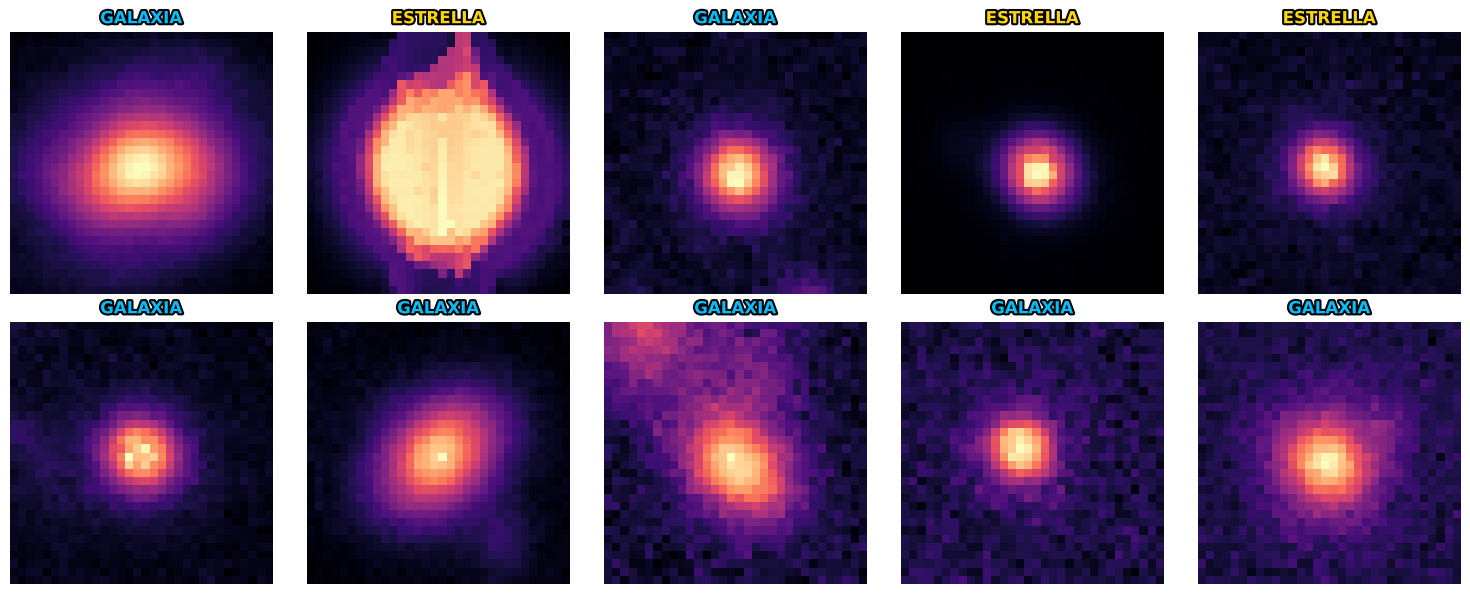

In [5]:


# 1. Carga de datos
with fits.open(file_subaru) as hdul:
    idx = 1 if len(hdul) > 1 else 0
    data_sub, wcs_sub = hdul[idx].data, WCS(hdul[idx].header)

# 2. Configurar el centro de la imagen (Subaru)
ra_img, dec_img = wcs_sub.all_pix2world(data_sub.shape[1]/2, data_sub.shape[0]/2, 0)
centro_coords = SkyCoord(ra=ra_img*u.deg, dec=dec_img*u.deg, frame='icrs')

# 3. Calcular dimensiones para el barrido
alto_px, ancho_px = data_sub.shape
# Escala de píxel en grados
pixel_scale = np.abs(wcs_sub.pixel_scale_matrix[0,0]) 
ancho_grados = ancho_px * pixel_scale
alto_grados = alto_px * pixel_scale


# 4. Inicializar el Manager
manager = SubaruDatasetManager(data_sub, wcs_sub)

# --- INICIO DEL BARRIDO CON MONITOREO ---
num_regiones = 5
paso_grados = ancho_grados * 0.15 

print(f" Iniciando barrido de {num_regiones} regiones...")

for i in range(num_regiones):
    offset_ra = (np.cos(i) * i/num_regiones) * paso_grados
    offset_dec = (np.sin(i) * i/num_regiones) * paso_grados
    
    nuevo_centro = SkyCoord(ra=(centro_coords.ra.deg + offset_ra)*u.deg, 
                            dec=(centro_coords.dec.deg + offset_dec)*u.deg, frame='icrs')
    
    px, py = wcs_sub.all_world2pix(nuevo_centro.ra.deg, nuevo_centro.dec.deg, 0)
    
    if 0 <= px < ancho_px and 0 <= py < alto_px:
        print(f"\n--- Escaneando Región {i+1}/{num_regiones} ---")
        
        try:
            manager.escanear_campo_robusto(nuevo_centro, radius_arcmin=10.0)
            
            # --- MONITOR DE CRECIMIENTO ---
            # Mostramos cuántos objetos llevamos en total en el manager
            total_actual = len(manager.objetos_validados)
            print(f"📈 Objetos acumulados en memoria: {total_actual}")
            
            if i < num_regiones - 1:
                time.sleep(1.5)
                
        except Exception as e:
            print(f" Error en región {i+1}: {e}")
    else:
        print(f"⏩ Región {i+1} fuera de límites, saltando...")


# 1. Extracción: Obtenemos la lista base de diccionarios
dataset_final = manager.generar_dataset_clasificado(box_size=16, snr_min=15.5)

if dataset_final:
    # 2. Construcción (FE): Creamos el DataFrame de características a partir de 'stats'
    # Esto cumple con "Se crean características nuevas y significativas"
    df_raw = pd.DataFrame([
        {**d['stats'], 'target': d['label']} for d in dataset_final
    ])
    
    # 3. Selección y Escalamiento (Rúbrica: Normalización / Selección)
    # Aquí pasamos el DataFrame a la función de selección que definimos antes
    df_final = manager.seleccionar_caracteristicas(df_raw)
    
    print("\n  Ingeniería de Características Completada")
    print(f" Registros procesados: {len(df_final)}")
    print(df_final.head())
    
    # 4. Visualización
    manager.visualizar_clasificados(dataset_final, n=10)
else:
    print(" No se generaron datos. Verifica el SNR o el barrido de regiones.")


In [6]:
# Inicializar sesión de Spark correctamente
spark = SparkSession.builder \
    .appName("AstroDatasetPreparation") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate() 

print("Sesión de Spark iniciada correctamente")

26/05/17 06:40:12 WARN Utils: Your hostname, MacBook-Pro-de-Uriel.local resolves to a loopback address: 127.0.0.1; using 192.168.0.29 instead (on interface en0)
26/05/17 06:40:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/17 06:40:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/17 06:40:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Sesión de Spark iniciada correctamente


In [7]:
def enriquecer_objeto(obj):
    """
    Toma un objeto del dataset y genera 4 versiones:
    Original, rotación 90°, 180° y Flip Horizontal.
    """
    img = obj['img']
    versiones = []
    
    # 1. Original
    versiones.append(img)
    # 2. Rotación 90 grados
    versiones.append(rotate(img, 90, reshape=False))
    # 3. Rotación 180 grados
    versiones.append(rotate(img, 180, reshape=False))
    # 4. Flip Horizontal (Espejo)
    versiones.append(np.fliplr(img))
    
    return versiones

def guardar_dataset_parquet_pro(dataset, path="subaru_dataset_final.parquet"):
    rows = []
    print(f"🔄 Procesando {len(dataset)} objetos originales...")

    for obj in dataset:
        # Data Augmentation (Ingeniería de Características: Variabilidad)
        imagenes_aumentadas = enriquecer_objeto(obj)
        
        for img_aug in imagenes_aumentadas:
            # Normalización Local [0, 1]
            # Justificación: Vital para que la Red Neuronal no sature sus funciones de activación
            v_min, v_max = np.min(img_aug), np.max(img_aug)
            img_norm = (img_aug - v_min) / (v_max - v_min) if v_max > v_min else img_aug

            # Split Aleatorio (Consistente con CRISP-ML)
            rand_val = random.random()
            dataset_type = "train" if rand_val < 0.80 else "validation" if rand_val < 0.90 else "test"

            # Flattening para Parquet
            img_flat = img_norm.flatten().tolist()
            
            # Mapeo de IDs (3: Galaxia, 6: Estrella según SDSS)
            c_id = 3 if obj['label'] == "GALAXIA" else 6
            
            rows.append({
                "ra": float(obj['ra']), # Ya no dará KeyError
                "dec": float(obj['dec']),
                "label": str(obj['label']),
                "class_id": int(c_id),
                "pixels": img_flat,
                "type": dataset_type 
            })

    # Esquema estricto para consumo en Redes Neuronales
    schema = StructType([
        StructField("ra", DoubleType(), True),
        StructField("dec", DoubleType(), True),
        StructField("label", StringType(), True),
        StructField("class_id", IntegerType(), True),
        StructField("pixels", ArrayType(DoubleType()), True),
        StructField("type", StringType(), True)
    ])

    df = spark.createDataFrame(rows, schema)

    # Particionado físico (Data Pruning)
    # Esto acelera el entrenamiento al cargar solo la carpeta /type=train/
    df.write.partitionBy("type").mode("overwrite").parquet(path)
    
    print(f" Dataset guardado en {path}")
    df.groupBy("type", "label").count().show()


In [8]:
# 1. Guardar en Parquet (Este paso lo haces en el Jupyter actual)
guardar_dataset_parquet_pro(dataset_final, path="subaru_training_data.parquet")



🔄 Procesando 6159 objetos originales...


26/05/17 06:40:39 WARN TaskSetManager: Stage 0 contains a task of very large size (27758 KiB). The maximum recommended task size is 1000 KiB.


 Dataset guardado en subaru_training_data.parquet


26/05/17 06:40:49 WARN TaskSetManager: Stage 1 contains a task of very large size (27758 KiB). The maximum recommended task size is 1000 KiB.


+----------+--------+-----+
|      type|   label|count|
+----------+--------+-----+
|      test|ESTRELLA|  935|
|     train|ESTRELLA| 7405|
|validation|ESTRELLA|  960|
|      test| GALAXIA| 1537|
|     train| GALAXIA|12284|
|validation| GALAXIA| 1515|
+----------+--------+-----+



In [9]:
try:
    if 'spark' in locals() or 'spark' in globals():
        print("⏳ Cerrando sesión de Spark...")
        spark.stop()
        print(" Sesión finalizada correctamente.")
    else:
        print(" No se detectó ninguna sesión activa para cerrar.")
except Exception as e:
    print(f" Ocurrió un error al intentar cerrar Spark: {e}")
finally:
    # Opcional: Eliminar la referencia de la variable para liberar memoria
    if 'spark' in locals():
        del spark

⏳ Cerrando sesión de Spark...
 Sesión finalizada correctamente.


### ***Conclusiones de la Fase: Preparación de Datos***

***

### ***1. Construcción y Enriquecimiento***
* Se crearon nuevas variables estadísticas como la **media, desviación estándar y valor máximo** de la luz para cada objeto. Esto ayuda a diferenciar mejor entre una galaxia y una estrella.
* Se aplicó **Data Augmentation** creando 4 versiones de cada imagen (original, rotaciones y espejo). Esto sirve para que el modelo aprenda a reconocer el objeto sin importar cómo esté orientado en el cielo.

### ***2. Normalización y Transformación***
* Se usó la función **asinh** para que los brillos extremos de las estrellas no "ceguen" al modelo y se puedan ver los detalles de las galaxias débiles.
* Todas las imágenes se ajustaron a un rango de **0 a 1 (Min-Max)**. Esto es fundamental para que la red neuronal aprenda más rápido y no tenga errores de cálculo por números muy grandes.

### ***3. Selección de Datos***
* Se borraron los objetos **duplicados** que aparecían en el cruce de las regiones escaneadas durante el barrido.
* Se usó un filtro de **SNR (Relación Señal-Ruido)** para eliminar imágenes con mucho ruido, dejando solo los objetos que se ven con claridad.

### ***4. Almacenamiento Estructurado***
* El dataset se guardó en formato **Parquet**, dividiéndolo automáticamente en carpetas de **entrenamiento, validación y prueba** mediante Spark.
* Este formato permite que el proceso de entrenamiento de la red neuronal cargue los datos de forma mucho más veloz desde el disco.

### ***Cumplimiento con CRISP-ML***
Este Jupyter cumple con la fase de **Preparación de Datos** porque entrega un dataset limpio, sin ruido, con los datos ya escalados y particionados. Se logró pasar de imágenes astronómicas crudas a un archivo estructurado y optimizado para la fase de Modelado.